In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Coding\Machine_Learning\Machine Learning Coding\Multiple Linear Regression\Practice Problems\Closed Form\Dataset\multiple_linear_regression_dataset.csv")
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [3]:
age_scaled = (df['age'] - np.min(df['age']))/(np.max(df['age']) - np.min(df['age']))
experience_scaled = (df['experience'] - np.min(df['experience']))/(np.max(df['experience']) - np.min(df['experience']))
income_scaled = (df['income'] - np.min(df['income']))/(np.max(df['income']) - np.min(df['income']))

X = np.column_stack([np.ones(len(df)),age_scaled,experience_scaled])
Y = np.array(income_scaled)
Y = Y.reshape(-1, 1)

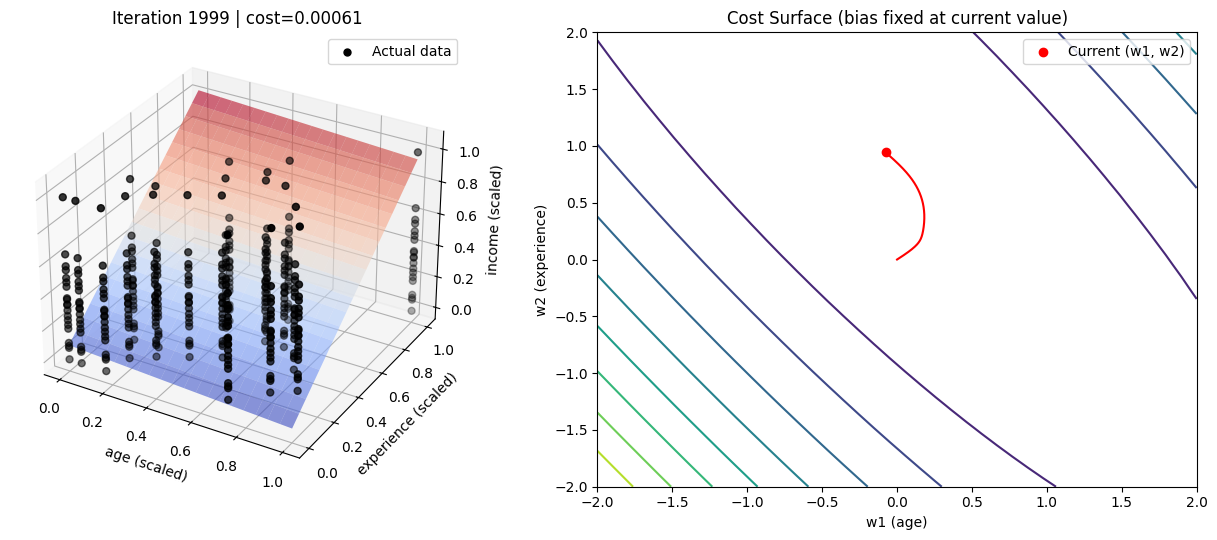

Weight after training:  [[ 0.09020541]
 [-0.07586056]
 [ 0.94288681]]
Cost after training:  0.0006138467229509651


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from IPython import display

w1_range = np.linspace(-2, 2, 40)
w2_range = np.linspace(-2, 2, 40)
W1, W2 = np.meshgrid(w1_range, w2_range)

def cost_for_w1_w2(w0_fixed, w1_val, w2_val):
    w_test = np.array([[w0_fixed], [w1_val], [w2_val]])
    Y_pred_grid = X @ w_test
    return (1 / (2 * len(X))) * np.sum((Y_pred_grid - Y) ** 2)

# --- Grid for the regression PLANE (age, experience both scaled 0-1) ---
age_plane_range = np.linspace(0, 1, 20)
exp_plane_range = np.linspace(0, 1, 20)
AGE_PLANE, EXP_PLANE = np.meshgrid(age_plane_range, exp_plane_range)

# --- Gradient descent ---
w = np.zeros((X.shape[1], 1))
ALPHA = 0.06
iterations = 2000
cost_history = []
w1_history = []
w2_history = []
m = len(Y)

for i in range(iterations):
    Y_pred = X @ w
    error = Y_pred - Y

    cost = (1 / (2 * m)) * np.sum(error ** 2)
    cost_history.append(cost)
    w1_history.append(w[1, 0])
    w2_history.append(w[2, 0])

    w = w - (ALPHA / m) * (X.T @ error)

    if i % 50 == 0 or i == iterations - 1:
        display.clear_output(wait=True)

        fig = plt.figure(figsize=(13, 5.5))

        # Left: 3D regression plane
        ax1 = fig.add_subplot(1, 2, 1, projection='3d')
        Z_plane = w[0, 0] + w[1, 0] * AGE_PLANE + w[2, 0] * EXP_PLANE
        ax1.plot_surface(AGE_PLANE, EXP_PLANE, Z_plane, cmap='coolwarm', alpha=0.6, edgecolor='none')
        ax1.scatter(X[:, 1], X[:, 2], Y, color='black', s=25, label='Actual data')
        ax1.set_xlabel("age (scaled)")
        ax1.set_ylabel("experience (scaled)")
        ax1.set_zlabel("income (scaled)")
        ax1.set_title(f"Iteration {i} | cost={cost:.5f}")
        ax1.legend()

        # Right: w1/w2 cost contour with descent path
        Z = np.zeros_like(W1)
        for row in range(W1.shape[0]):
            for col in range(W1.shape[1]):
                Z[row, col] = cost_for_w1_w2(w[0, 0], W1[row, col], W2[row, col])

        ax2 = fig.add_subplot(1, 2, 2)
        levels = np.linspace(Z.min(), Z.max(), 10)
        ax2.contour(W1, W2, Z, levels=levels, cmap='viridis')
        ax2.plot(w1_history, w2_history, color='red')
        ax2.scatter([w[1, 0]], [w[2, 0]], color='red', label='Current (w1, w2)')
        ax2.set_xlabel("w1 (age)")
        ax2.set_ylabel("w2 (experience)")
        ax2.set_title("Cost Surface (bias fixed at current value)")
        ax2.legend()

        plt.tight_layout()
        plt.show()
        plt.close(fig)   

print("Weight after training: ", w)
print("Cost after training: ", cost_history[-1])

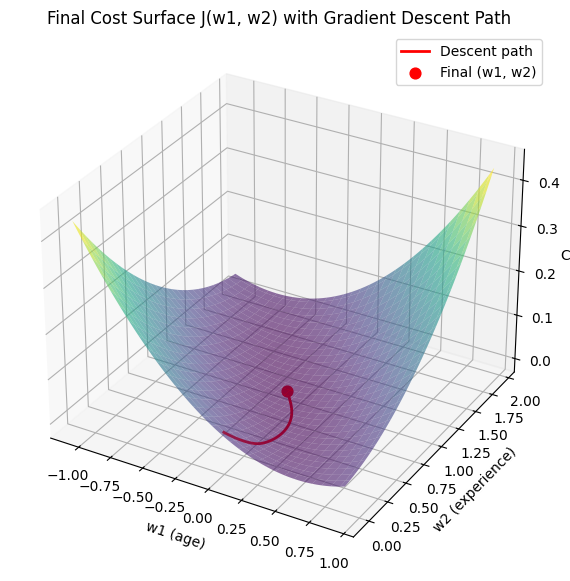

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def cost_for_w1_w2(w0_fixed, w1_val, w2_val):
    w_test = np.array([[w0_fixed], [w1_val], [w2_val]])
    Y_pred_grid = X @ w_test
    return (1 / (2 * len(X))) * np.sum((Y_pred_grid - Y) ** 2)

# Grid centered around the FINAL trained w1, w2
w1_range = np.linspace(w[1, 0] - 1, w[1, 0] + 1, 60)
w2_range = np.linspace(w[2, 0] - 1, w[2, 0] + 1, 60)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z = np.zeros_like(W1)
for row in range(W1.shape[0]):
    for col in range(W1.shape[1]):
        Z[row, col] = cost_for_w1_w2(w[0, 0], W1[row, col], W2[row, col])

# Cost at each point along the recorded descent path (for the path's height)
path_cost = [cost_for_w1_w2(w[0, 0], w1_history[i], w2_history[i]) for i in range(len(w1_history))]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax.plot(w1_history, w2_history, path_cost, color='red', linewidth=2, label='Descent path')
ax.scatter([w[1, 0]], [w[2, 0]], [path_cost[-1]], color='red', s=60, label='Final (w1, w2)')

ax.set_xlabel("w1 (age)")
ax.set_ylabel("w2 (experience)")
ax.set_zlabel("Cost")
ax.set_title("Final Cost Surface J(w1, w2) with Gradient Descent Path")
ax.legend()

plt.show()